<h1> Материалы курса "Анализ данных в инфромационной безопасности" </h1>

Анализ данных работы промышленной установки Сингапурского университета (SUTD)

https://itrust.sutd.edu.sg/itrust-labs-home/itrust-labs_swat/


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.__version__

'3.0.2'

# 1. Чтение, первичное преобразование и сохранение данных

In [48]:
#filename = 'SWaT_Dataset_Normal_v1.xlsx'
filename = 'SWaT_Dataset_Normal_v1.csv'

pd.read_csv(filename, nrows=10, decimal=',')

,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,...,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Normal/Attack
0,22/12/2015 4:30:00 PM,0,124.3135,1,1,1,251.9226,8.313446,312.7916,0,...,1,1,9.100231,0,3.3485,0.000256,1,1,1,Normal
1,22/12/2015 4:30:01 PM,0,124.3920,1,1,1,251.9226,8.313446,312.7916,0,...,1,1,9.100231,0,3.3485,0.000256,1,1,1,Normal
2,22/12/2015 4:30:02 PM,0,124.4705,1,1,1,251.9226,8.313446,312.7916,0,...,1,1,9.100231,0,3.3485,0.000256,1,1,1,Normal
3,22/12/2015 4:30:03 PM,0,124.6668,1,1,1,251.9226,8.313446,312.7916,0,...,1,1,9.100231,0,3.3485,0.000256,1,1,1,Normal
4,22/12/2015 4:30:04 PM,0,124.5098,1,1,1,251.9226,8.313446,312.7916,0,...,1,1,9.100231,0,3.3485,0.000256,1,1,1,Normal
5,22/12/2015 4:30:05 PM,0,123.9210,1,1,1,251.9226,8.313446,312.7916,0,...,1,1,9.100231,0,3.3485,0.000256,1,1,1,Normal
6,22/12/2015 4:30:06 PM,0,123.5284,1,1,1,251.9226,8.313446,312.7916,0,...,1,1,9.100231,0,3.3485,0.000256,1,1,1,Normal
7,22/12/2015 4:30:07 PM,0,123.4107,1,1,1,251.9226,8.313446,312.7916,0,...,1,1,9.100231,0,3.3485,0.000256,1,1,1,Normal
8,22/12/2015 4:30:08 PM,0,123.2144,1,1,1,251.9226,8.312805,312.7916,0,...,1,1,9.100231,0,3.3485,0.000256,1,1,1,Normal
9,22/12/2015 4:30:09 PM,0,123.3322,1,1,1,251.9226,8.310242,312.7916,0,...,1,1,9.100231,0,3.3485,0.000256,1,1,1,Normal


In [49]:
%%time


df = pd.read_csv(
    filename, nrows=20_000,
    header=0,
    decimal=","
    #index_col=0
)
df

CPU times: total: 62.5 ms
Wall time: 63 ms


,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,...,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Normal/Attack
0,22/12/2015 4:30:00 PM,0.000000,124.3135,1,1,1,251.9226,8.313446,312.7916,0.000000,...,1,1,9.100231,0.000000,3.3485,0.000256,1,1,1,Normal
1,22/12/2015 4:30:01 PM,0.000000,124.3920,1,1,1,251.9226,8.313446,312.7916,0.000000,...,1,1,9.100231,0.000000,3.3485,0.000256,1,1,1,Normal
2,22/12/2015 4:30:02 PM,0.000000,124.4705,1,1,1,251.9226,8.313446,312.7916,0.000000,...,1,1,9.100231,0.000000,3.3485,0.000256,1,1,1,Normal
3,22/12/2015 4:30:03 PM,0.000000,124.6668,1,1,1,251.9226,8.313446,312.7916,0.000000,...,1,1,9.100231,0.000000,3.3485,0.000256,1,1,1,Normal
4,22/12/2015 4:30:04 PM,0.000000,124.5098,1,1,1,251.9226,8.313446,312.7916,0.000000,...,1,1,9.100231,0.000000,3.3485,0.000256,1,1,1,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,22/12/2015 10:03:15 PM,2.443391,503.4166,2,2,1,261.2791,8.339080,437.4263,2.460898,...,2,1,254.229700,1.105309,193.3479,0.000128,1,1,1,Normal
19996,22/12/2015 10:03:16 PM,2.427057,503.4559,2,2,1,261.2791,8.339080,437.4263,2.460898,...,2,1,254.229700,1.057252,193.3479,0.000128,1,1,1,Normal
19997,22/12/2015 10:03:17 PM,2.424815,503.2596,2,2,1,261.2791,8.339080,437.4007,2.460898,...,2,1,254.229700,1.057252,193.3479,0.000128,1,1,1,Normal
19998,22/12/2015 10:03:18 PM,2.423854,503.2989,2,2,1,261.2791,8.339080,437.3494,2.463204,...,2,1,254.229700,1.057252,193.3479,0.000128,1,1,1,Normal


In [50]:
#преобразование метки времени из строки в тип timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format=" %d/%m/%Y %H:%M:%S %p")

In [51]:
df = df.set_index('Timestamp')

In [52]:
df['LIT101'][:10000].resample('1h').mean()

Timestamp
2015-12-22 04:00:00    202.121523
2015-12-22 05:00:00    287.186011
2015-12-22 06:00:00    327.408935
2015-12-22 07:00:00    352.526743
Freq: h, Name: LIT101, dtype: float64

In [53]:
df.dropna(axis=1, how='all')

,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,...,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Normal/Attack
Timestamp,,,,,,,,,,,,,,,,,,,,,
2015-12-22 04:30:00,0.000000,124.3135,1,1,1,251.9226,8.313446,312.7916,0.000000,1,...,1,1,9.100231,0.000000,3.3485,0.000256,1,1,1,Normal
2015-12-22 04:30:01,0.000000,124.3920,1,1,1,251.9226,8.313446,312.7916,0.000000,1,...,1,1,9.100231,0.000000,3.3485,0.000256,1,1,1,Normal
2015-12-22 04:30:02,0.000000,124.4705,1,1,1,251.9226,8.313446,312.7916,0.000000,1,...,1,1,9.100231,0.000000,3.3485,0.000256,1,1,1,Normal
2015-12-22 04:30:03,0.000000,124.6668,1,1,1,251.9226,8.313446,312.7916,0.000000,1,...,1,1,9.100231,0.000000,3.3485,0.000256,1,1,1,Normal
2015-12-22 04:30:04,0.000000,124.5098,1,1,1,251.9226,8.313446,312.7916,0.000000,1,...,1,1,9.100231,0.000000,3.3485,0.000256,1,1,1,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-12-22 10:03:15,2.443391,503.4166,2,2,1,261.2791,8.339080,437.4263,2.460898,2,...,2,1,254.229700,1.105309,193.3479,0.000128,1,1,1,Normal
2015-12-22 10:03:16,2.427057,503.4559,2,2,1,261.2791,8.339080,437.4263,2.460898,2,...,2,1,254.229700,1.057252,193.3479,0.000128,1,1,1,Normal
2015-12-22 10:03:17,2.424815,503.2596,2,2,1,261.2791,8.339080,437.4007,2.460898,2,...,2,1,254.229700,1.057252,193.3479,0.000128,1,1,1,Normal


In [54]:
df.shape

(20000, 52)

In [55]:
df.memory_usage(deep=True).sum() / 2**20

np.float64(8.983612060546875)

In [56]:
df.columns

Index(['FIT101', 'LIT101', 'MV101', 'P101', 'P102', 'AIT201', 'AIT202',
       'AIT203', 'FIT201', 'MV201', 'P201', 'P202', 'P203', 'P204', 'P205',
       'P206', 'DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302', 'MV303',
       'MV304', 'P301', 'P302', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'P401',
       'P402', 'P403', 'P404', 'UV401', 'AIT501', 'AIT502', 'AIT503', 'AIT504',
       'FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501', 'P502', 'PIT501',
       'PIT502', 'PIT503', 'FIT601', 'P601', 'P602', 'P603', 'Normal/Attack'],
      dtype='str')

In [57]:
filename = filename[:-5] + '_corr.csv'
filename

'SWaT_Dataset_Normal_v_corr.csv'

In [58]:
df.to_csv(filename, index=True)

# 2. Анализ данных

## 2.1. Загрузка обработанных данных

In [77]:
%%time
df = pd.read_csv(filename)
df.head(5)

CPU times: total: 78.1 ms
Wall time: 69.2 ms


,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,...,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Normal/Attack
0,2015-12-22 04:30:00,0.0,124.3135,1,1,1,251.9226,8.313446,312.7916,0.0,...,1,1,9.100231,0.0,3.3485,0.000256,1,1,1,Normal
1,2015-12-22 04:30:01,0.0,124.3920,1,1,1,251.9226,8.313446,312.7916,0.0,...,1,1,9.100231,0.0,3.3485,0.000256,1,1,1,Normal
2,2015-12-22 04:30:02,0.0,124.4705,1,1,1,251.9226,8.313446,312.7916,0.0,...,1,1,9.100231,0.0,3.3485,0.000256,1,1,1,Normal
3,2015-12-22 04:30:03,0.0,124.6668,1,1,1,251.9226,8.313446,312.7916,0.0,...,1,1,9.100231,0.0,3.3485,0.000256,1,1,1,Normal
4,2015-12-22 04:30:04,0.0,124.5098,1,1,1,251.9226,8.313446,312.7916,0.0,...,1,1,9.100231,0.0,3.3485,0.000256,1,1,1,Normal


## 2.2. Статистики по данным

In [78]:
df.info(verbose=False)

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Columns: 53 entries, Timestamp to Normal/Attack
dtypes: float64(24), int64(27), str(2)
memory usage: 8.1 MB


In [79]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
FIT101,20000.0,2.183535,0.890196,0.000000,2.437946,2.524741,2.609615,2.691285
LIT101,20000.0,451.521630,188.442469,120.623700,304.012600,358.024400,633.578800,815.083500
MV101,20000.0,1.854800,0.358083,0.000000,2.000000,2.000000,2.000000,2.000000
P101,20000.0,1.839100,0.367448,1.000000,2.000000,2.000000,2.000000,2.000000
P102,20000.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
AIT201,20000.0,262.500468,2.540524,251.666200,262.240400,262.464800,263.522200,266.341900
AIT202,20000.0,8.449632,0.197575,8.258652,8.350295,8.375608,8.423994,8.943733
AIT203,20000.0,461.421107,41.555312,312.791600,445.783100,464.368100,486.413700,548.423500
FIT201,20000.0,2.071276,0.906099,0.000000,2.461667,2.469100,2.472175,2.487810
MV201,20000.0,1.849400,0.366642,0.000000,2.000000,2.000000,2.000000,2.000000


### 2.2.1. Определение типа признаков (непрерывные, булевые, категориальные)

In [80]:
const_columns = []
bool_columns = []
cat_columns = []

for column in df.columns:
    nunique = df[column].nunique()
    match nunique:
        case 1:    
            print(f"column {column} has only one value: {df[column].unique()[0]}")
            const_columns.append(column)
        case 2:    
            print(f"column {column} has only two values: {df[column].unique()}")
            bool_columns.append(column)
        case _ if nunique < 5: 
            print(f"column {column} has only {nunique} values: {df[column].unique()}")
            cat_columns.append(column)

column MV101 has only 3 values: [1 0 2]
column P101 has only two values: [1 2]
column P102 has only one value: 1
column MV201 has only 3 values: [1 0 2]
column P201 has only one value: 1
column P202 has only one value: 1
column P203 has only two values: [1 2]
column P204 has only one value: 1
column P205 has only two values: [1 2]
column P206 has only one value: 1
column MV301 has only 3 values: [1 0 2]
column MV302 has only 3 values: [1 0 2]
column MV303 has only 3 values: [1 0 2]
column MV304 has only 3 values: [1 0 2]
column P301 has only two values: [1 2]
column P302 has only two values: [1 2]
column AIT401 has only one value: 0
column P401 has only one value: 1
column P402 has only two values: [1 2]
column P403 has only one value: 1
column P404 has only one value: 1
column UV401 has only two values: [1 2]
column P501 has only two values: [1 2]
column P502 has only one value: 1
column P601 has only one value: 1
column P602 has only two values: [1 2]
column P603 has only one value: 

### 2.2.2. Удаление признаков-констант

In [81]:
df = df.drop(const_columns, axis = 1)
df[bool_columns+cat_columns] = df[bool_columns+cat_columns].astype("category")
df.info(verbose=False)

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Columns: 40 entries, Timestamp to P602
dtypes: category(15), float64(24), str(1)
memory usage: 4.1 MB


In [82]:
df.head()

,Timestamp,FIT101,LIT101,MV101,P101,AIT201,AIT202,AIT203,FIT201,MV201,...,FIT501,FIT502,FIT503,FIT504,P501,PIT501,PIT502,PIT503,FIT601,P602
0,2015-12-22 04:30:00,0.0,124.3135,1,1,251.9226,8.313446,312.7916,0.0,1,...,0.001538,0.001409,0.001664,0.0,1,9.100231,0.0,3.3485,0.000256,1
1,2015-12-22 04:30:01,0.0,124.3920,1,1,251.9226,8.313446,312.7916,0.0,1,...,0.001538,0.001409,0.001664,0.0,1,9.100231,0.0,3.3485,0.000256,1
2,2015-12-22 04:30:02,0.0,124.4705,1,1,251.9226,8.313446,312.7916,0.0,1,...,0.001538,0.001409,0.001664,0.0,1,9.100231,0.0,3.3485,0.000256,1
3,2015-12-22 04:30:03,0.0,124.6668,1,1,251.9226,8.313446,312.7916,0.0,1,...,0.001538,0.001409,0.001664,0.0,1,9.100231,0.0,3.3485,0.000256,1
4,2015-12-22 04:30:04,0.0,124.5098,1,1,251.9226,8.313446,312.7916,0.0,1,...,0.001538,0.001409,0.001664,0.0,1,9.100231,0.0,3.3485,0.000256,1


In [85]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'].str.strip(), format = "ISO8601")

In [89]:
df = df.set_index('Timestamp')

<Axes: xlabel='Timestamp'>

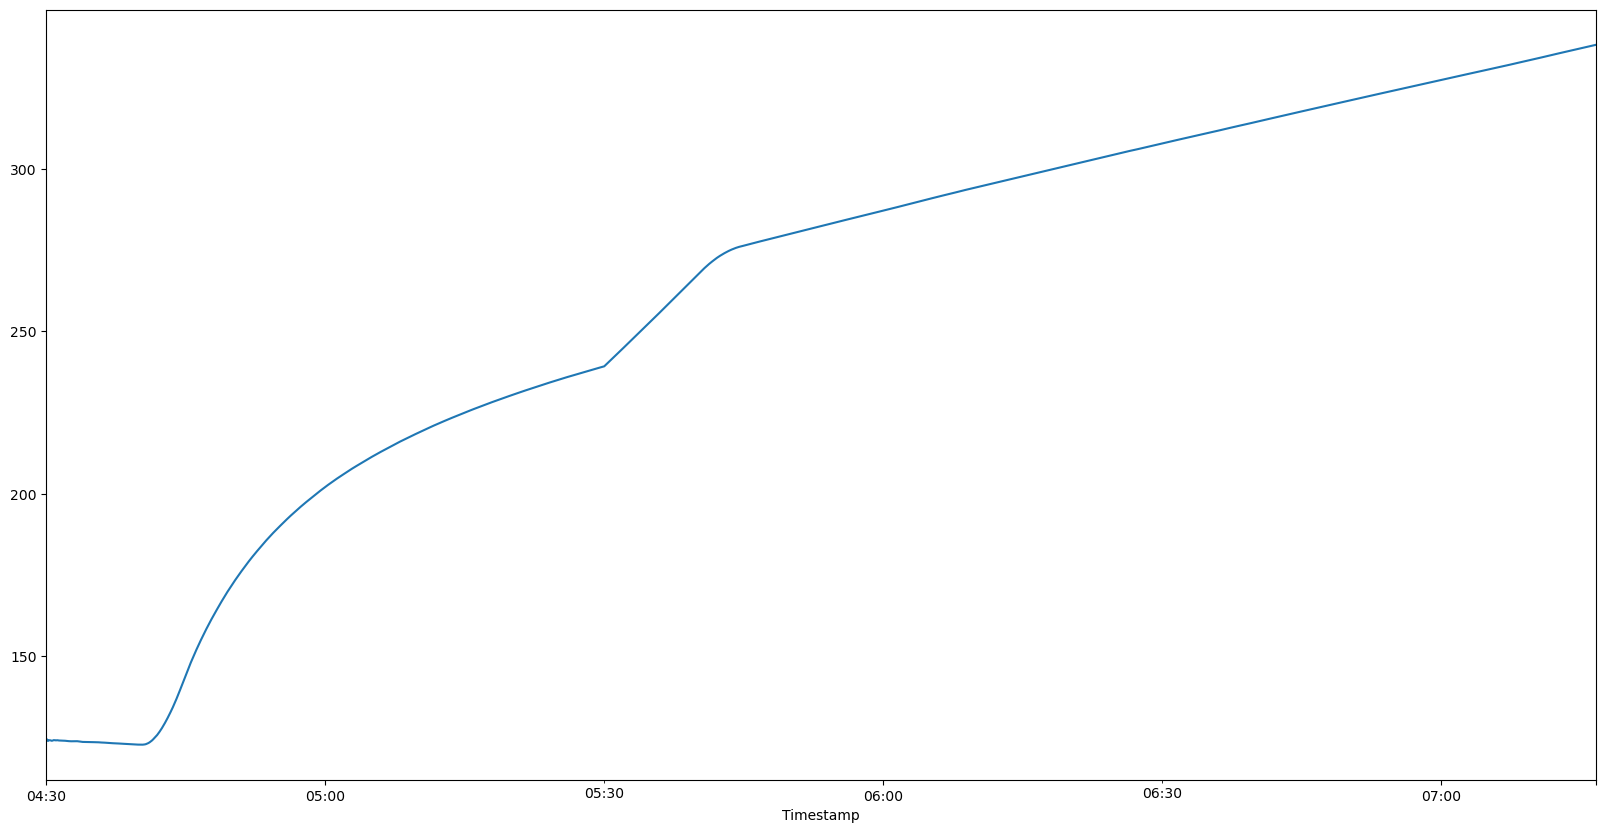

In [90]:
df['LIT101'][:10000].rolling("1h").mean().plot(figsize=(20,10))

## 2.4. Анализ непрерывных и категориальных признаков

In [91]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
FIT101,20000.0,2.183535,0.890196,0.000000,2.437946,2.524741,2.609615,2.691285
LIT101,20000.0,451.521630,188.442469,120.623700,304.012600,358.024400,633.578800,815.083500
AIT201,20000.0,262.500468,2.540524,251.666200,262.240400,262.464800,263.522200,266.341900
AIT202,20000.0,8.449632,0.197575,8.258652,8.350295,8.375608,8.423994,8.943733
AIT203,20000.0,461.421107,41.555312,312.791600,445.783100,464.368100,486.413700,548.423500
FIT201,20000.0,2.071276,0.906099,0.000000,2.461667,2.469100,2.472175,2.487810
DPIT301,20000.0,16.949564,6.127232,0.025610,18.026120,19.546710,20.202960,21.099300
FIT301,20000.0,1.889122,0.735992,0.000000,2.118438,2.202991,2.223489,2.355059
LIT301,20000.0,713.304091,247.464680,132.818500,551.621400,808.606800,904.866125,1014.724000
AIT402,20000.0,203.061756,15.268859,169.238700,193.950300,199.512900,212.157125,235.708800


В категориальные запишем в т.ч. булевые, для упрощения. Остальные - в непрерывные

In [92]:
cat_columns = bool_columns+cat_columns
cont_columns = list(set(df.columns) - set(cat_columns))
cont_columns

['FIT101',
 'FIT502',
 'AIT504',
 'LIT101',
 'FIT504',
 'FIT501',
 'PIT501',
 'AIT202',
 'FIT301',
 'AIT203',
 'FIT401',
 'FIT201',
 'FIT601',
 'AIT503',
 'LIT401',
 'PIT503',
 'LIT301',
 'AIT402',
 'AIT201',
 'AIT502',
 'DPIT301',
 'FIT503',
 'PIT502',
 'AIT501']

### 2.4.1. Непрерывные признаки

Формула для оценки плотности ядра:

$$\hat{f}_h(x) = \frac{1}{n}\sum_{i=1}^{n} K_h(x - x_i) = \frac{1}{nh}\sum_{i=1}^{n} K\!\left(\frac{x - x_i}{h}\right)$$


В случае гауссова ядра (только этот вариант поддерживает Pandas)

$$\hat{f}_h(x) = \frac{1}{n}\sum_{i=1}^{n} \frac{1}{h\sqrt{2\pi}} \exp\!\left(\frac{-(x-x_i)^2}{2h^2}\right)$$

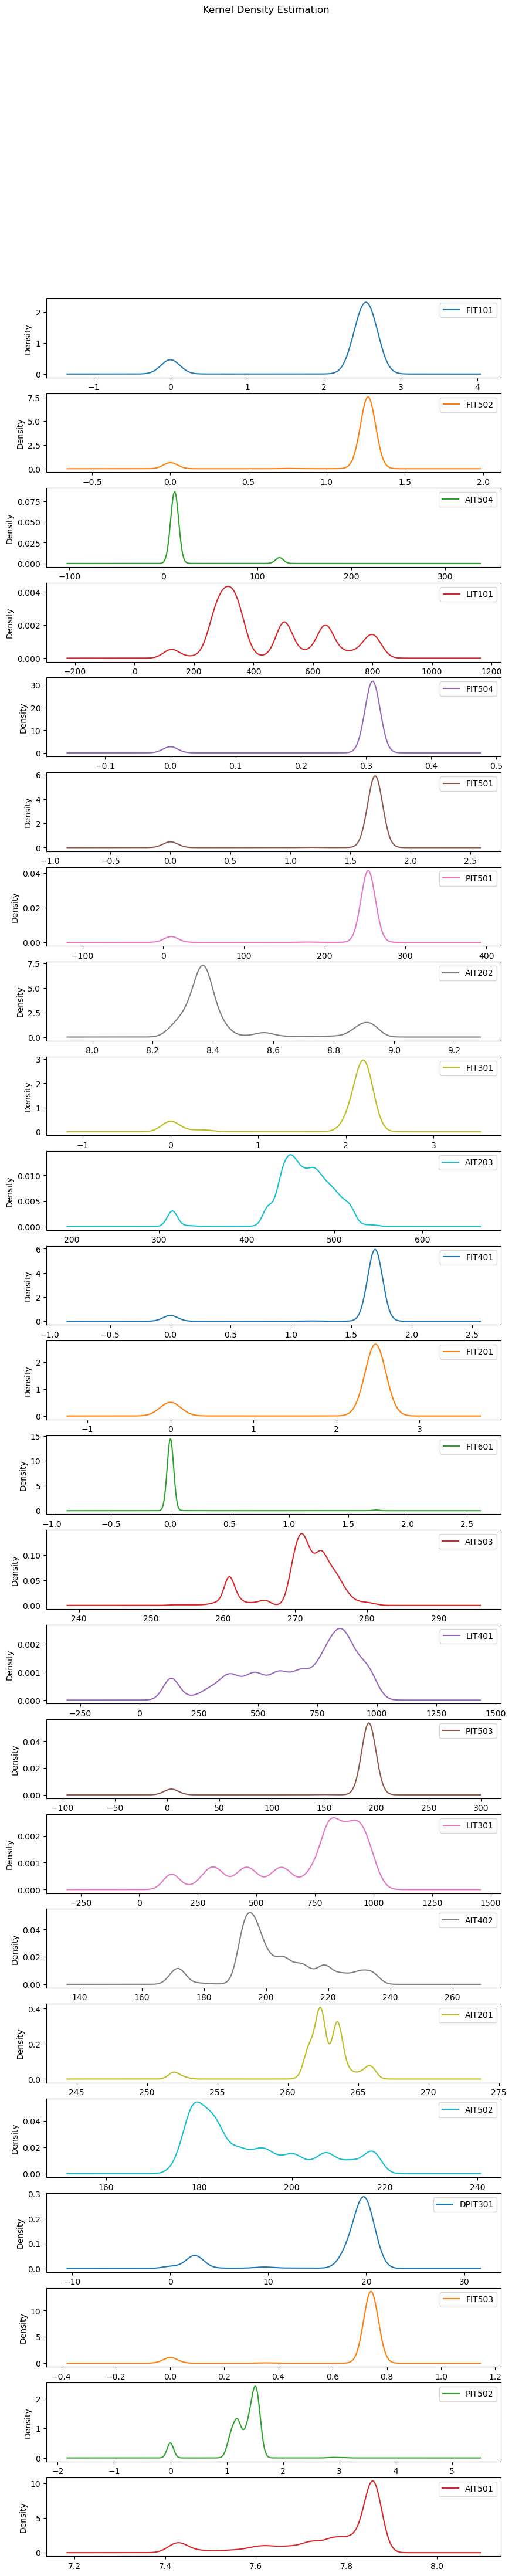

In [93]:
#определение возможного распределения значений величины
df[cont_columns].plot(
    kind='kde', 
    figsize=(10,50),
    subplots=True,
    sharex=False, 
    title='Kernel Density Estimation'
)

plt.show()

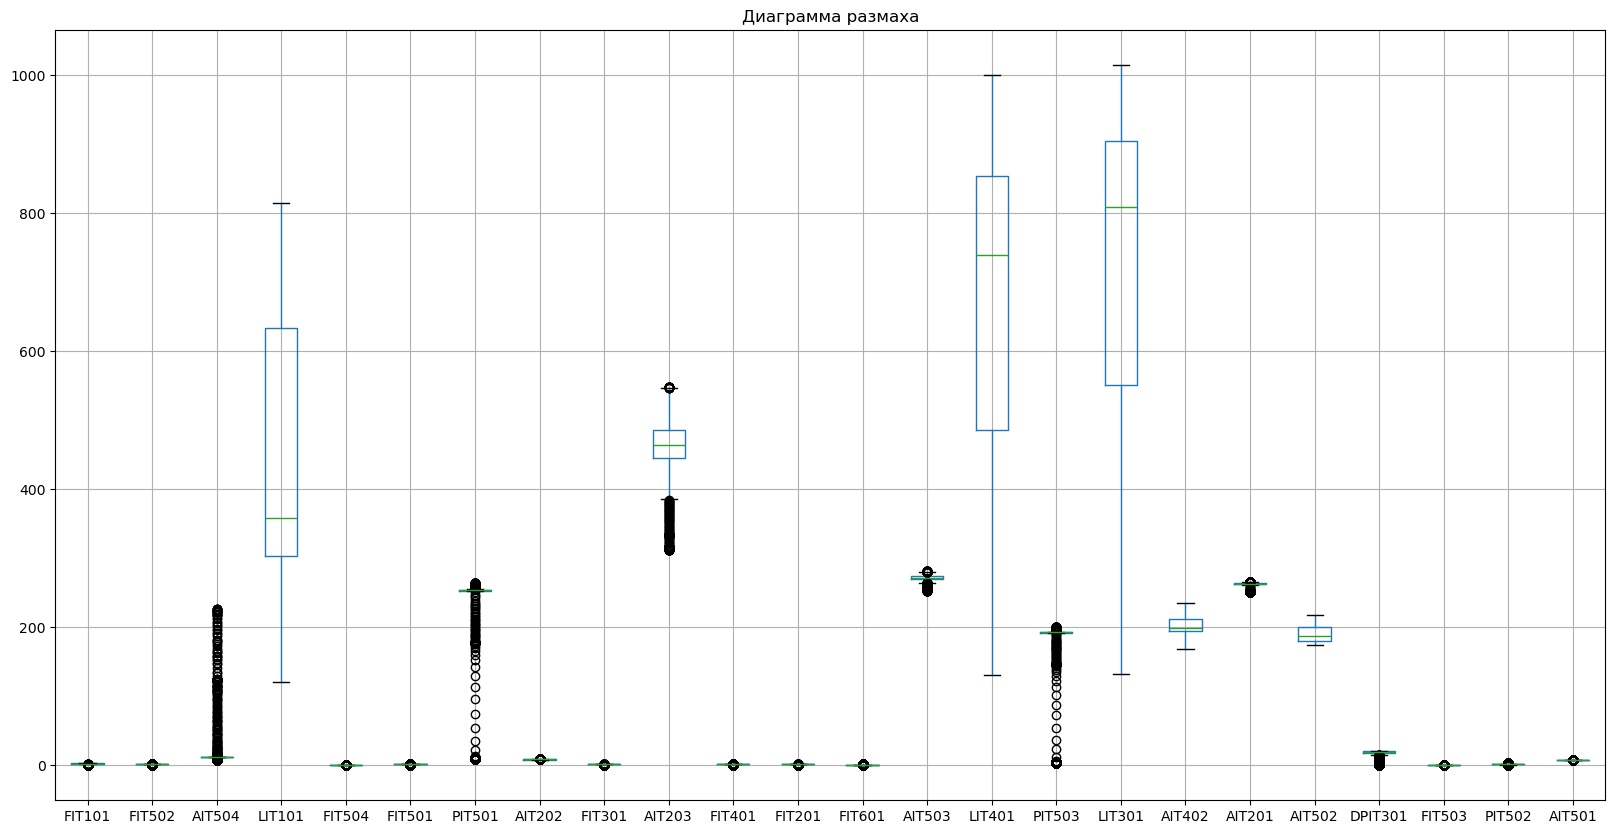

In [94]:
df[cont_columns].boxplot(figsize=(20,10))
plt.title("Диаграмма размаха")
plt.show()

### 2.4.2. Категориальные/булевые признаки

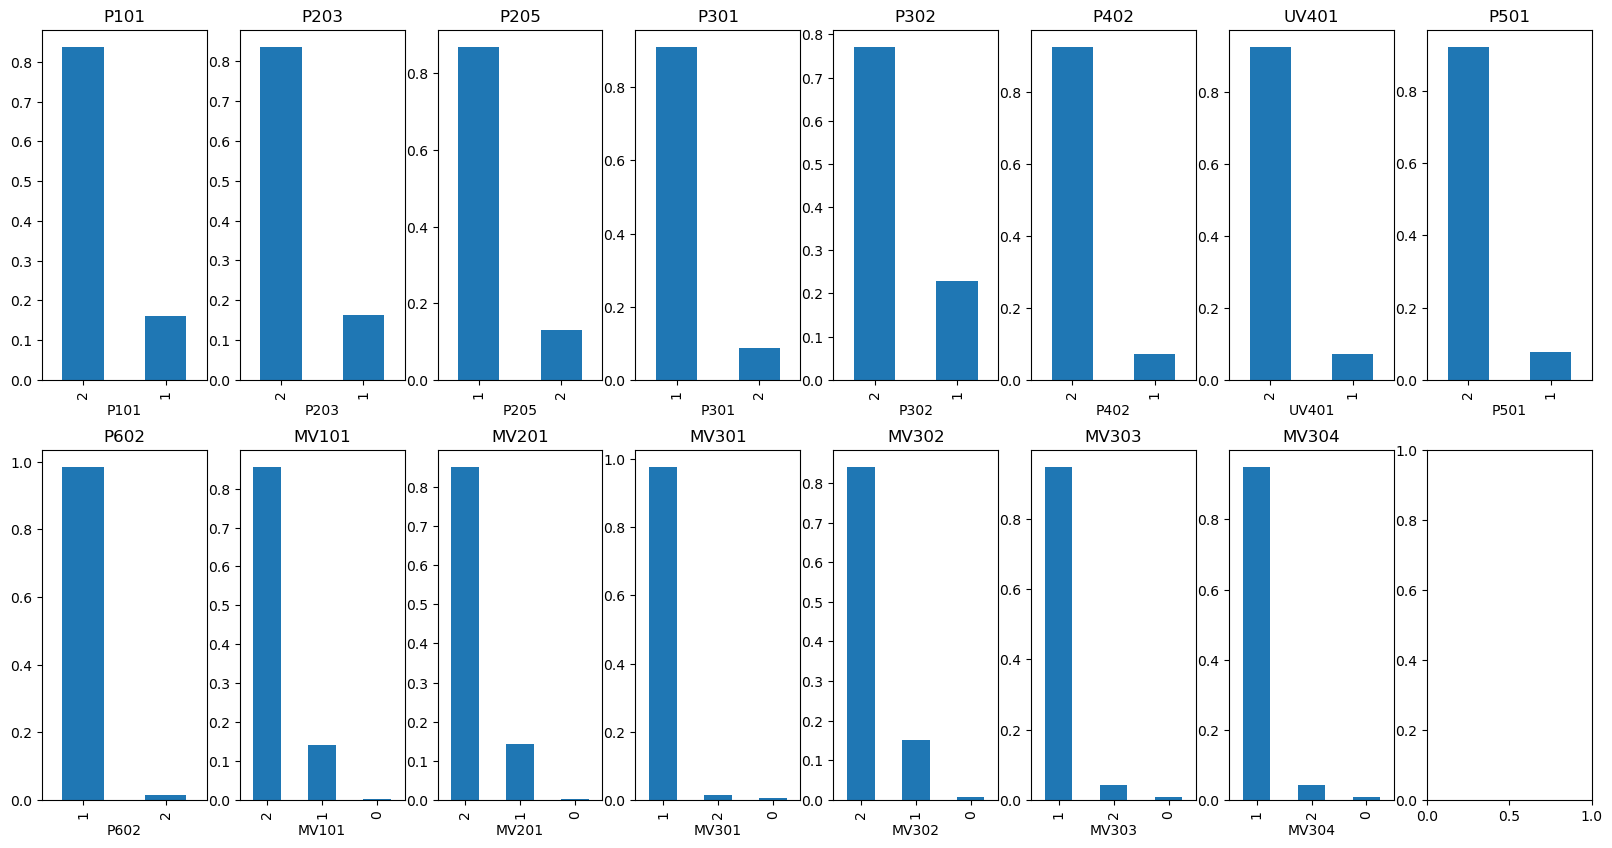

In [95]:
ncols = 8
nrows = len(cat_columns) // ncols
if len(cat_columns) % ncols != 0: nrows += 1

fig, axes = plt.subplots(ncols=ncols, nrows=nrows, figsize=(20,10))


for row, ax_row in enumerate(axes):
    for ax, col in zip(ax_row, cat_columns[row*ncols:(row+1)*ncols]):
        df[col].value_counts(normalize=True).plot.bar(ax=ax, title=col)




### 2.4.2. Анализ корреляции

<Axes: >

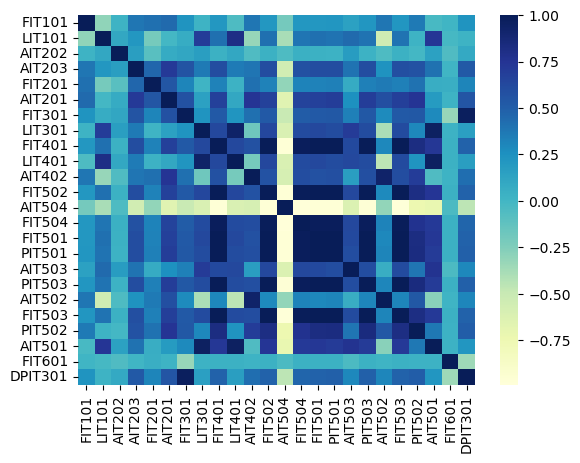

In [97]:
#plt.figure(figsize=(10,10))
sns.heatmap(df[sorted(cont_columns, key=lambda x: x[3])].corr(), cmap="YlGnBu")

In [98]:
df_corr = df[sorted(cont_columns, key=lambda x: x[3])].corr()

Найдем наиболее скоррелированные признаки

In [99]:
from itertools import combinations

unique_pairs = list(combinations(df_corr.columns, 2))
most_correlated = pd.DataFrame(columns=['1st', '2nd', 'value'])

for row, col in unique_pairs:
    corr_value = df_corr.loc[row, col]
    if corr_value >= 0.75:
        most_correlated.loc[most_correlated.shape[0]] = pd.Series({'1st': row, '2nd': col, 'value': corr_value})

most_correlated.sort_values('value', ascending=False)

,1st,2nd,value
6,FIT401,FIT501,0.999984
28,PIT501,PIT503,0.999857
7,FIT401,PIT501,0.99922
24,FIT501,PIT501,0.999205
8,FIT401,PIT503,0.999052
25,FIT501,PIT503,0.99902
14,FIT502,FIT501,0.998668
4,FIT401,FIT502,0.998642
29,PIT501,FIT503,0.998187
26,FIT501,FIT503,0.997959


# 3. Работа с временным рядом

## 3.1. Визуализация пропущенных значений

Можно использовать тепловую карту из sns и метод isna для датафрейма, но мы будем использовать модуль missingno - так проще, но его надо установить

pip install missingno

<Axes: >

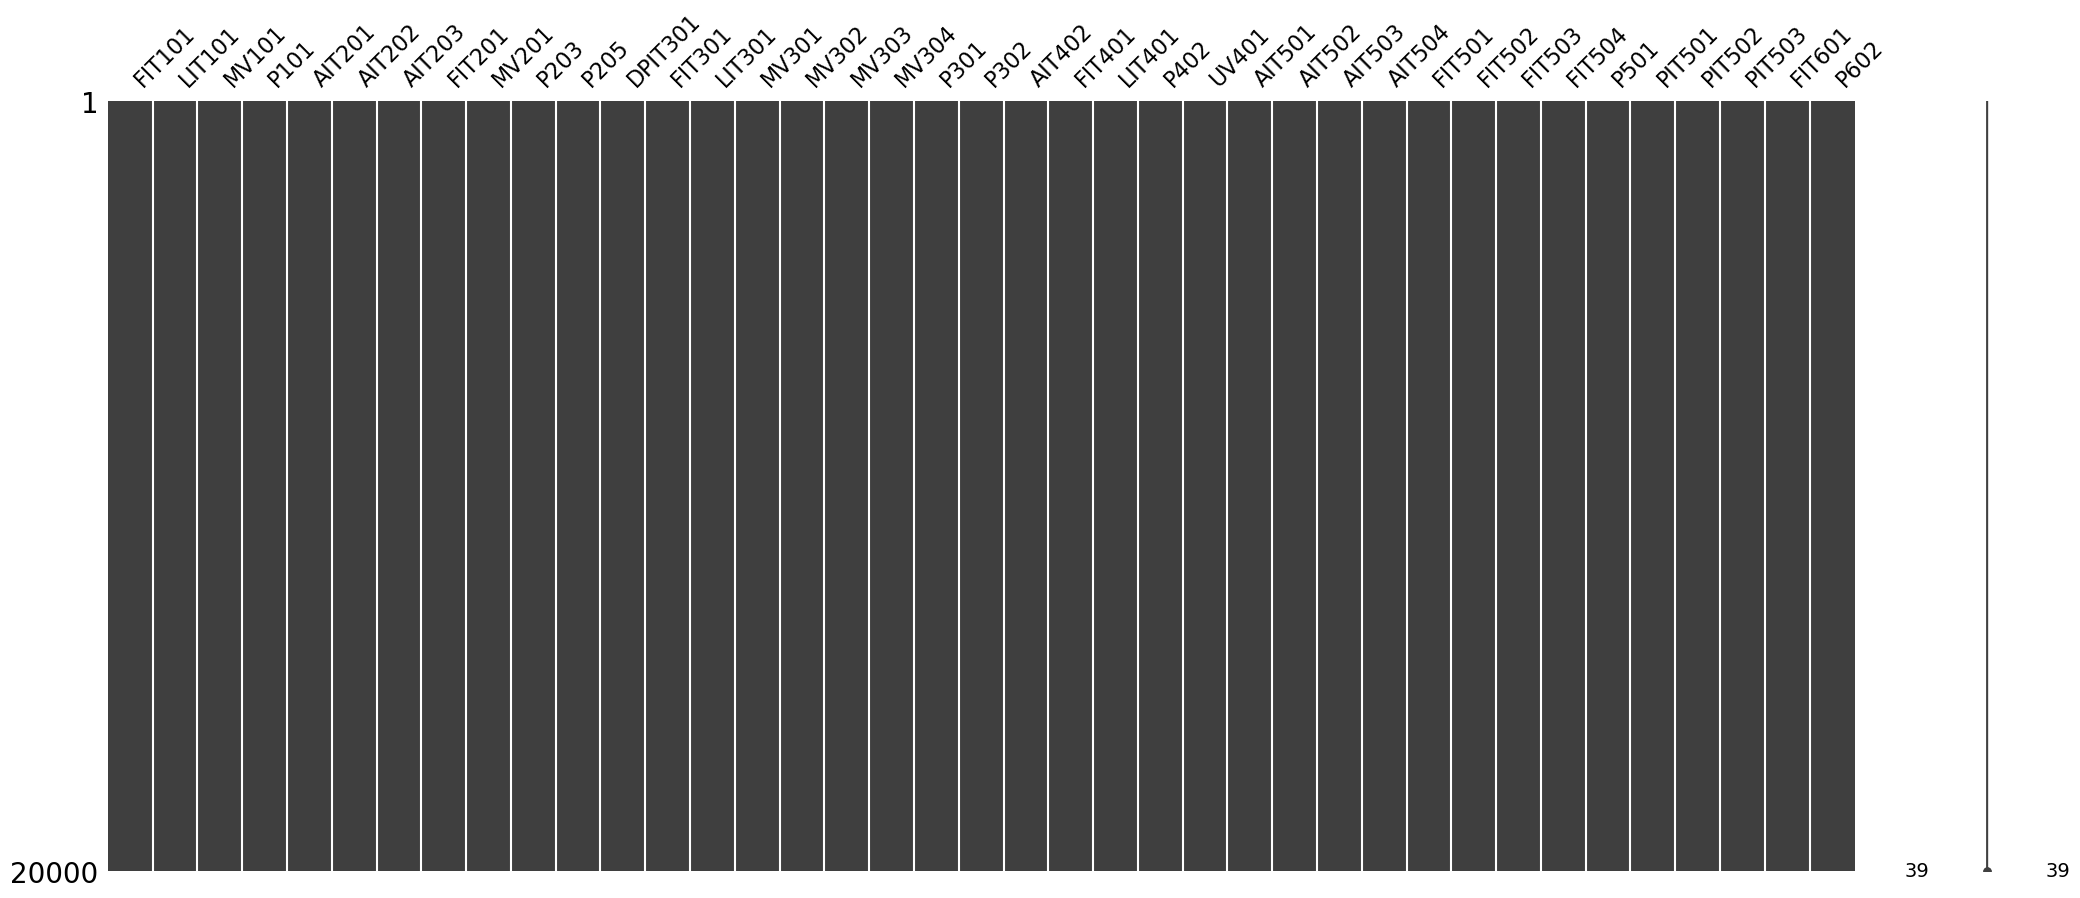

In [101]:
import missingno

missingno.matrix(df)

In [102]:
df.isna().sum()

FIT101     0
LIT101     0
MV101      0
P101       0
AIT201     0
AIT202     0
AIT203     0
FIT201     0
MV201      0
P203       0
P205       0
DPIT301    0
FIT301     0
LIT301     0
MV301      0
MV302      0
MV303      0
MV304      0
P301       0
P302       0
AIT402     0
FIT401     0
LIT401     0
P402       0
UV401      0
AIT501     0
AIT502     0
AIT503     0
AIT504     0
FIT501     0
FIT502     0
FIT503     0
FIT504     0
P501       0
PIT501     0
PIT502     0
PIT503     0
FIT601     0
P602       0
dtype: int64

пропущенных значений нет, можно было бы это понять из info, но если бы были - эта визуализация бы нам помогла

## 3.2. Ресэмплирование и сглаживание

In [103]:
df.head(5)

,FIT101,LIT101,MV101,P101,AIT201,AIT202,AIT203,FIT201,MV201,P203,...,FIT501,FIT502,FIT503,FIT504,P501,PIT501,PIT502,PIT503,FIT601,P602
Timestamp,,,,,,,,,,,,,,,,,,,,,
2015-12-22 04:30:00,0.0,124.3135,1,1,251.9226,8.313446,312.7916,0.0,1,1,...,0.001538,0.001409,0.001664,0.0,1,9.100231,0.0,3.3485,0.000256,1
2015-12-22 04:30:01,0.0,124.3920,1,1,251.9226,8.313446,312.7916,0.0,1,1,...,0.001538,0.001409,0.001664,0.0,1,9.100231,0.0,3.3485,0.000256,1
2015-12-22 04:30:02,0.0,124.4705,1,1,251.9226,8.313446,312.7916,0.0,1,1,...,0.001538,0.001409,0.001664,0.0,1,9.100231,0.0,3.3485,0.000256,1
2015-12-22 04:30:03,0.0,124.6668,1,1,251.9226,8.313446,312.7916,0.0,1,1,...,0.001538,0.001409,0.001664,0.0,1,9.100231,0.0,3.3485,0.000256,1
2015-12-22 04:30:04,0.0,124.5098,1,1,251.9226,8.313446,312.7916,0.0,1,1,...,0.001538,0.001409,0.001664,0.0,1,9.100231,0.0,3.3485,0.000256,1


Изначально данные в датафрейме идут каждую секунду.

Предположим, что наши процессы достаточно инерционные и нам хватает периода в 1 минуту - это будет влиять на скорость обработки данных, их объем.
При помощи функции resample мы будем аггрегировать данные по 1 минуте, считая среднее значение за минуту. Применим это преобразование только к непрерывным признакам, т.к. для категориальных нет такого понятия как "среднее"

In [104]:
df_1min = df[cont_columns].resample('1min').mean()
df_1min.head(5)

,FIT101,FIT502,AIT504,LIT101,FIT504,FIT501,PIT501,AIT202,FIT301,AIT203,...,LIT401,PIT503,LIT301,AIT402,AIT201,AIT502,DPIT301,FIT503,PIT502,AIT501
Timestamp,,,,,,,,,,,,,,,,,,,,,
2015-12-22 04:30:00,0.000000,0.001409,123.381805,124.158442,0.000000,0.001538,9.079136,8.310001,0.000256,312.933878,...,133.086390,3.348500,137.999468,169.287813,251.922600,175.408857,2.560983,0.001664,0.0,7.444827
2015-12-22 04:31:00,0.000016,0.001409,123.347197,123.908527,0.000000,0.001538,9.068188,8.309750,0.000256,313.296585,...,132.646765,3.348500,137.562883,169.565088,251.922600,175.632332,2.561677,0.001664,0.0,7.444641
2015-12-22 04:32:00,0.000000,0.001409,123.340152,123.548057,0.000017,0.001538,9.068188,8.311182,0.000256,313.669147,...,132.498727,3.291090,136.653002,169.691108,251.916190,175.797222,2.564185,0.001664,0.0,7.442937
2015-12-22 04:33:00,0.000000,0.001409,123.355538,123.040390,0.000000,0.001538,9.068188,8.310124,0.000256,313.957082,...,132.446173,3.260382,137.310540,169.833363,251.841938,175.976200,2.564185,0.001664,0.0,7.440187
2015-12-22 04:34:00,0.000000,0.001409,123.354890,123.389078,0.000000,0.001538,9.068188,8.310087,0.000256,314.210027,...,132.327617,3.255843,136.822560,170.149130,251.841435,176.083923,2.564185,0.001664,0.0,7.439844


Также мы можем применить к этим данным сглаживание

In [105]:
df_rolling = df[cont_columns].rolling(60).mean()

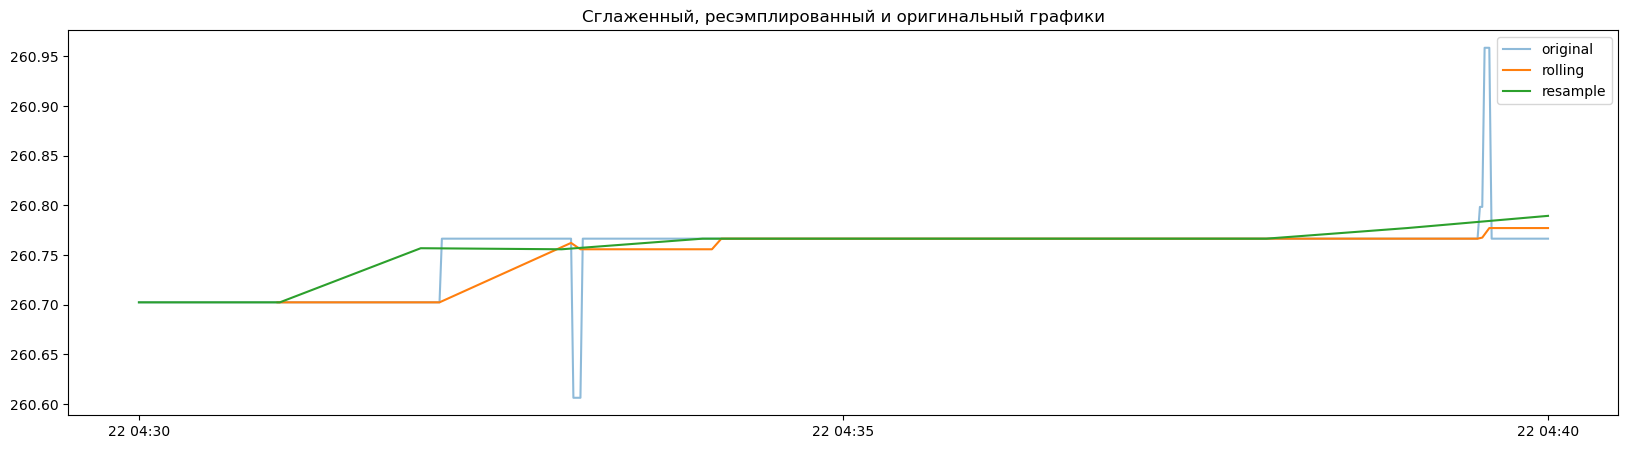

In [108]:
col = 'AIT503'

plt.figure(figsize=(20,5))

plt.plot(df[col].loc['2015-12-22 04:30:00':'2015-12-22 04:40:00'], alpha=0.5, label='original')
plt.plot(df_rolling[col].loc['2015-12-22 04:30:00':'2015-12-22 04:40:00'], label='rolling')
plt.plot(df_1min[col].loc['2015-12-22 04:30:00':'2015-12-22 04:40:00'], label='resample')

plt.title('Сглаженный, ресэмплированный и оригинальный графики')
plt.legend()
plt.show()